- Esse notebook terá a modelagem das IAs, e sua, consequente, execução e análise.

- A decisão foi manter dois modelos, o Random Forest e o XGB, para ir fazendo comparações entre eles.

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import itertools
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [2]:
# dataframe vindo do notebook anterior
caminho_arquivo = 'nfl_features_ml_2021_2025.parquet'

try:
    df_ml = pd.read_parquet(caminho_arquivo)
    print(f"Dataset carregado com sucesso! Total de jogos: {len(df_ml)}")
except Exception as e:
    print("Tentando carregar CSV como fallback...")
    df_ml = pd.read_csv('nfl_features_ml_2021_2025.csv')

Dataset carregado com sucesso! Total de jogos: 1339


In [3]:
# verificação básica
print("\nPrimeiras linhas:")
display(df_ml.head(10))


Primeiras linhas:


,season,week,home_team,away_team,home_score,away_score,home_offense_pts_last3,home_offense_pts_season,home_defense_pts_last3,home_defense_pts_season,...,away_offense_pts_season,away_defense_pts_last3,away_defense_pts_season,away_total_yards_last3,away_total_yards_season,away_yards_per_play_last3,away_yards_per_play_season,away_turnovers_last3,away_turnovers_season,target
0,2021,2,WAS,NYG,30,29,16.0,16.0,20.0,20.0,...,13.0,27.0,27.0,327.0,327.0,5.736842,5.736842,1.0,1.0,1
1,2021,2,CAR,NO,26,7,19.0,19.0,14.0,14.0,...,38.0,3.0,3.0,322.0,322.0,5.366667,5.366667,0.0,0.0,1
2,2021,2,CHI,CIN,20,17,14.0,14.0,34.0,34.0,...,27.0,24.0,24.0,410.0,410.0,6.507937,6.507937,0.0,0.0,1
3,2021,2,CLE,HOU,31,21,29.0,29.0,33.0,33.0,...,37.0,21.0,21.0,451.0,451.0,6.094595,6.094595,0.0,0.0,1
4,2021,2,IND,LA,24,27,16.0,16.0,28.0,28.0,...,34.0,14.0,14.0,395.0,395.0,8.061224,8.061224,0.0,0.0,0
5,2021,2,JAX,DEN,13,23,21.0,21.0,37.0,37.0,...,27.0,13.0,13.0,429.0,429.0,6.703125,6.703125,1.0,1.0,0
6,2021,2,MIA,BUF,0,35,17.0,17.0,16.0,16.0,...,16.0,23.0,23.0,387.0,387.0,5.092105,5.092105,1.0,1.0,0
7,2021,2,NYJ,NE,6,25,14.0,14.0,19.0,19.0,...,16.0,17.0,17.0,406.0,406.0,5.884058,5.884058,2.0,2.0,0
8,2021,2,PHI,SF,11,17,32.0,32.0,6.0,6.0,...,41.0,33.0,33.0,450.0,450.0,8.333333,8.333333,2.0,2.0,0
9,2021,2,PIT,LV,17,26,23.0,23.0,16.0,16.0,...,33.0,27.0,27.0,517.0,517.0,6.714286,6.714286,1.0,1.0,0


In [4]:
print(df_ml.columns)

Index(['season', 'week', 'home_team', 'away_team', 'home_score', 'away_score',
       'home_offense_pts_last3', 'home_offense_pts_season',
       'home_defense_pts_last3', 'home_defense_pts_season',
       'home_total_yards_last3', 'home_total_yards_season',
       'home_yards_per_play_last3', 'home_yards_per_play_season',
       'home_turnovers_last3', 'home_turnovers_season',
       'away_offense_pts_last3', 'away_offense_pts_season',
       'away_defense_pts_last3', 'away_defense_pts_season',
       'away_total_yards_last3', 'away_total_yards_season',
       'away_yards_per_play_last3', 'away_yards_per_play_season',
       'away_turnovers_last3', 'away_turnovers_season', 'target'],
      dtype='str')


- GridSearch pra encontrar a melhor combinação dentre as features, sempre colocando elas em pacotes coerentes.

In [5]:
# 1. Definindo os Blocos Simétricos (Mandante e Visitante SEMPRE alinhados)
opcoes_pts = [
    [], # Sem pontos
    ['home_offense_pts_last3', 'home_defense_pts_last3', 'away_offense_pts_last3', 'away_defense_pts_last3'], # Só Last3
    ['home_offense_pts_season', 'home_defense_pts_season', 'away_offense_pts_season', 'away_defense_pts_season'], # Só Season
    ['home_offense_pts_last3', 'home_defense_pts_last3', 'away_offense_pts_last3', 'away_defense_pts_last3',
     'home_offense_pts_season', 'home_defense_pts_season', 'away_offense_pts_season', 'away_defense_pts_season'] # Ambos (O antigo Baseline)
]

opcoes_ypp = [
    [], 
    ['home_yards_per_play_last3', 'away_yards_per_play_last3'], 
    ['home_yards_per_play_season', 'away_yards_per_play_season'], 
    ['home_yards_per_play_last3', 'away_yards_per_play_last3', 'home_yards_per_play_season', 'away_yards_per_play_season']
]

opcoes_turnovers = [
    [], 
    ['home_turnovers_last3', 'away_turnovers_last3'], 
    ['home_turnovers_season', 'away_turnovers_season'], 
    ['home_turnovers_last3', 'away_turnovers_last3', 'home_turnovers_season', 'away_turnovers_season']
]

opcoes_yards = [
    [], 
    ['home_total_yards_last3', 'away_total_yards_last3'], 
    ['home_total_yards_season', 'away_total_yards_season'], 
    ['home_total_yards_last3', 'away_total_yards_last3', 'home_total_yards_season', 'away_total_yards_season']
]

# Separação cronológica
df_train = df_ml[df_ml['season'] < 2025]
df_test = df_ml[df_ml['season'] == 2025]
y_train = df_train['target']
y_test = df_test['target']

resultados = []

print("Iniciando varredura de 256 combinações lógicas. Isso pode levar um minutinho...")

# 2. Gerando o Produto Cartesiano (Todas as combinações possíveis entre os blocos)
for combo in itertools.product(opcoes_pts, opcoes_ypp, opcoes_turnovers, opcoes_yards):
    pts_feats, ypp_feats, turn_feats, yards_feats = combo
    
    # Junta todas as features ativas nesta combinação
    features_ativas = pts_feats + ypp_feats + turn_feats + yards_feats
    
    # Ignora se a combinação estiver 100% vazia
    if len(features_ativas) == 0:
        continue
        
    # Preparando descrições para a tabela final
    desc_pts = "Ambos" if len(pts_feats) == 8 else ("Season" if "season" in str(pts_feats) else ("Last3" if "last3" in str(pts_feats) else "Desligado"))
    desc_ypp = "Ambos" if len(ypp_feats) == 4 else ("Season" if "season" in str(ypp_feats) else ("Last3" if "last3" in str(ypp_feats) else "Desligado"))
    desc_turn = "Ambos" if len(turn_feats) == 4 else ("Season" if "season" in str(turn_feats) else ("Last3" if "last3" in str(turn_feats) else "Desligado"))
    desc_yards = "Ambos" if len(yards_feats) == 4 else ("Season" if "season" in str(yards_feats) else ("Last3" if "last3" in str(yards_feats) else "Desligado"))
    
    # Separando Treino e Teste para esta combinação específica
    X_train = df_train[features_ativas]
    X_test = df_test[features_ativas]
    
    # Treinando um XGBoost rápido (usando parâmetros padrão para ter uma base rápida)
    xgb_grid = XGBClassifier(n_estimators=100, 
        max_depth=3, 
        learning_rate=0.05, 
        random_state=42, 
        eval_metric='logloss')
    xgb_grid.fit(X_train, y_train)
    
    # Prevendo e medindo a Acurácia base (sem o filtro de toss-up, apenas acurácia bruta para ranking rápido)
    preds = xgb_grid.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    # Salvando os resultados
    resultados.append({
        'Pts': desc_pts,
        'YPP': desc_ypp,
        'Turnovers': desc_turn,
        'Jardas': desc_yards,
        'Qtd_Features': len(features_ativas),
        'Acuracia_Bruta': acc,
        'Features_Lista': features_ativas # Guardamos a lista para você copiar a vencedora depois!
    })

# 3. Exibindo o Top 10 Estratégias
df_ranking = pd.DataFrame(resultados).sort_values(by='Acuracia_Bruta', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 COMBINAÇÕES DE FEATURES ===")
display(df_ranking[['Pts', 'YPP', 'Turnovers', 'Jardas', 'Qtd_Features', 'Acuracia_Bruta']].head(10))

Iniciando varredura de 256 combinações lógicas. Isso pode levar um minutinho...

=== TOP 10 COMBINAÇÕES DE FEATURES ===


,Pts,YPP,Turnovers,Jardas,Qtd_Features,Acuracia_Bruta
0,Ambos,Desligado,Ambos,Desligado,12,0.634686
1,Ambos,Desligado,Last3,Desligado,10,0.634686
2,Season,Desligado,Last3,Desligado,6,0.634686
3,Season,Desligado,Desligado,Desligado,4,0.619926
4,Season,Desligado,Ambos,Desligado,8,0.619926
5,Ambos,Desligado,Season,Last3,12,0.616236
6,Last3,Desligado,Ambos,Desligado,8,0.612546
7,Ambos,Desligado,Season,Desligado,10,0.612546
8,Ambos,Desligado,Ambos,Last3,14,0.608856
9,Ambos,Season,Last3,Desligado,12,0.608856


- Agora fazendo gridsearch dos hiperparametros, levando a combinação do índice 1, que pareceu promissora:

In [6]:
# 1. Definindo as features da Linha 1 (O nosso pacote promissor)
features_tuning = [
    # Pts (Ambos: EWMA/Last3 + Season)
    'home_offense_pts_last3', 'home_defense_pts_last3', 
    'home_offense_pts_season', 'home_defense_pts_season',
    'away_offense_pts_last3', 'away_defense_pts_last3', 
    'away_offense_pts_season', 'away_defense_pts_season',
    
    # Turnovers (Ambos: EWMA/Last3 + Season)
    'home_turnovers_last3', 'home_turnovers_season',
    'away_turnovers_last3', 'away_turnovers_season'
]

# Separando Treino e Teste
X_train_tune = df_train[features_tuning]
y_train_tune = df_train['target']
X_test_tune = df_test[features_tuning]
y_test_tune = df_test['target']

# 2. Definindo a grade de busca (O "Cardápio" de Hiperparâmetros)
param_grid = {
    'max_depth': [3, 4, 5],               # Profundidade da árvore (4 ou 5 dão espaço para os Turnovers)
    'learning_rate': [0.01, 0.05, 0.1],   # Velocidade de aprendizado
    'n_estimators': [100, 200, 300],      # Quantidade de árvores
    'subsample': [0.8, 1.0]               # Amostragem de dados para evitar overfitting
}

print("Iniciando o GridSearch de Hiperparâmetros... Isso exige poder de fogo da máquina!")

# 3. Configurando o modelo base e o GridSearch
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5,                 # Validação Cruzada (Cross-Validation) de 5 dobras no Treino
    n_jobs=-1,            # Usa todos os núcleos do seu processador
    verbose=1
)

# 4. Treinando o GridSearch
grid_search.fit(X_train_tune, y_train_tune)

# 5. Extraindo o vencedor
melhor_xgb = grid_search.best_estimator_
melhores_params = grid_search.best_params_

print("\n=== RESULTADO DA OTIMIZAÇÃO ===")
print(f"Melhores Hiperparâmetros Encontrados:\n{melhores_params}")

# Testando na prática (Ano de 2025)
preds_tune = melhor_xgb.predict(X_test_tune)
acc_tune = accuracy_score(y_test_tune, preds_tune)
print(f"\nAcurácia Bruta no Teste (2025) com o modelo otimizado: {acc_tune:.4f}")

Iniciando o GridSearch de Hiperparâmetros... Isso exige poder de fogo da máquina!
Fitting 5 folds for each of 54 candidates, totalling 270 fits



=== RESULTADO DA OTIMIZAÇÃO ===
Melhores Hiperparâmetros Encontrados:
{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

Acurácia Bruta no Teste (2025) com o modelo otimizado: 0.6199


- Split temporal, reservando o ano mais recente pra teste.

In [7]:
features = [
    # Pts (Ambos: EWMA/Last3 + Season)
    'home_offense_pts_last3', 'home_defense_pts_last3', 
    'home_offense_pts_season', 'home_defense_pts_season',
    'away_offense_pts_last3', 'away_defense_pts_last3', 
    'away_offense_pts_season', 'away_defense_pts_season',
    
    # Turnovers (Ambos: EWMA/Last3 + Season)
    'home_turnovers_last3', 'home_turnovers_season',
    'away_turnovers_last3', 'away_turnovers_season'
]

# separação cronológica (Treino = 2021-2024, Teste = 2025)
df_train = df_ml[df_ml['season'] < 2025]
df_test = df_ml[df_ml['season'] == 2025]

X_train, y_train = df_train[features], df_train['target']
X_test, y_test = df_test[features], df_test['target']

- Os modelos em si:

In [8]:
# treinando o modelo otimizado
xgb = XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.01, 
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


- Avaliando de acordo com as métricas:

- Acurácia: taxa de acerto geral

- Precisão (Precision): Quando o modelo aposta na vitória do Mandante, qual a % de vezes que ele acerta de fato?

- Recall (Sensibilidade): De todas as vitórias reais do Mandante que ocorreram, quantas o modelo conseguiu "encontrar"?

- F1-Score: O equilíbrio matemático entre Precisão e Recall.

- ROC AUC: Mede o quão bem o modelo consegue separar os vencedores dos perdedores baseado em suas probabilidades (onde 50% é o mesmo que jogar uma moeda pro alto).

In [9]:
# as previsões "Duras" (0 ou 1) para Acurácia, Precisão, Recall e F1
xgb_preds = xgb.predict(X_test)

# as previsões de "Probabilidade" para o ROC AUC
# o [:, 1] pega apenas a probabilidade de a classe ser 1 (Vitória do Mandante)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [10]:
def imprimir_raio_x_modelo(nome_modelo, y_true, y_pred, y_prob):
    print(f"=== {nome_modelo} ===")
    print(f"Acurácia : {accuracy_score(y_true, y_pred):.2%}")
    print(f"Precisão : {precision_score(y_true, y_pred):.2%}")
    print(f"Recall   : {recall_score(y_true, y_pred):.2%}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.2%}")
    
    # ROC AUC exige que as duas classes (0 e 1) estejam presentes no y_true para não dar erro
    if len(np.unique(y_true)) > 1:
        print(f"ROC AUC  : {roc_auc_score(y_true, y_prob):.2%}")
    else:
        print(f"ROC AUC  : N/A (Apenas uma classe no filtro)")
    print("=" * 40)

In [11]:
# exibindo os resultados do modelo em todos os jogos (Acurácia Bruta)
imprimir_raio_x_modelo("XGBoost (Acurácia Bruta - Sem Filtro)", y_test, xgb_preds, xgb_probs)

=== XGBoost (Acurácia Bruta - Sem Filtro) ===
Acurácia : 61.99%
Precisão : 62.87%
Recall   : 71.92%
F1-Score : 67.09%
ROC AUC  : 67.46%


- Aplicando o conceito de Toss-up, se o modelo estiver com uma probabilidade entre 45% e 55%, não dê palpite. É um jogo imprevisível.

In [12]:
# definindo as fronteiras do Toss-Up (jogos imprevisíveis)
limite_inferior = 0.45
limite_superior = 0.55

def aplicar_filtro_tossup(nome_modelo, y_true, probs):
    y_true_array = np.array(y_true)
    probs_array = np.array(probs)
    
    # filtro: Pega só onde o modelo tem convicção (< 45% ou > 55%)
    jogos_confiantes = (probs_array < limite_inferior) | (probs_array > limite_superior)
    
    y_true_filtrado = y_true_array[jogos_confiantes]
    probs_filtrado = probs_array[jogos_confiantes]
    
    # gera a previsão dura (0 ou 1) para as métricas
    previsoes_finais = (probs_filtrado > 0.50).astype(int)
    
    total_jogos = len(y_true)
    jogos_apostados = len(y_true_filtrado)
    jogos_ignorados = total_jogos - jogos_apostados
    
    print(f"\n=== {nome_modelo} (Filtro Toss-Up 45%-55%) ===")
    
    if jogos_apostados == 0:
        print("O modelo não teve confiança em NENHUM jogo!")
        print("-" * 40)
        return
        
    print(f"Jogos Avaliados: {jogos_apostados}/{total_jogos} | Ignorados: {jogos_ignorados} ({jogos_ignorados/total_jogos:.1%})")
    
    # chama a função reaproveitada (passando um texto descritivo para o título interno)
    imprimir_raio_x_modelo("Métricas Filtradas", y_true_filtrado, previsoes_finais, probs_filtrado)

# aplica a função apenas para o XGBoost
aplicar_filtro_tossup("XGBoost", y_test, xgb_probs)


=== XGBoost (Filtro Toss-Up 45%-55%) ===
Jogos Avaliados: 154/271 | Ignorados: 117 (43.2%)
=== Métricas Filtradas ===
Acurácia : 67.53%
Precisão : 69.72%
Recall   : 81.72%
F1-Score : 75.25%
ROC AUC  : 71.53%


=== RANKING DE IMPORTÂNCIA DAS FEATURES (XGBoost) ===


,Feature,Importancia
0,home_offense_pts_season,0.134670
1,away_offense_pts_season,0.130413
2,away_offense_pts_last3,0.088757
3,home_offense_pts_last3,0.083841
4,away_turnovers_season,0.077424
5,away_turnovers_last3,0.077308
6,home_turnovers_season,0.071781
7,home_defense_pts_last3,0.070892
8,away_defense_pts_season,0.069743
9,away_defense_pts_last3,0.067618


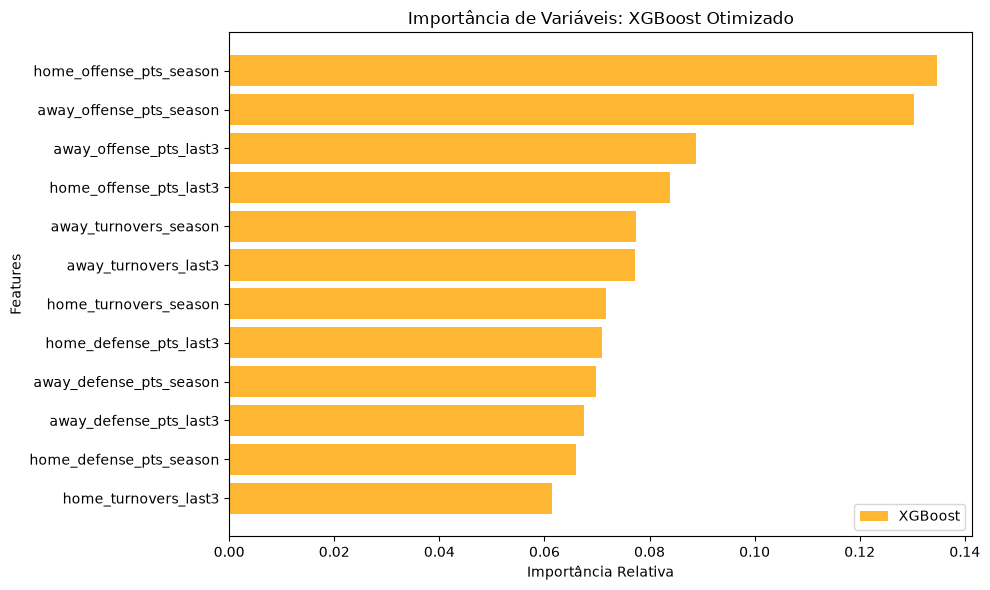

In [13]:
# Garante que temos a lista com o nome de todas as colunas de treino
features_names = [col for col in X_train.columns]

# 1. Extraindo a importância do XGBoost
importancia_xgb = xgb.feature_importances_

# 2. Montando um DataFrame para facilitar a visualização e ordenação
df_importancia = pd.DataFrame({
    'Feature': features_names,
    'Importancia': importancia_xgb
})

# Ordenando pela importância
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).reset_index(drop=True)

print("=== RANKING DE IMPORTÂNCIA DAS FEATURES (XGBoost) ===")
display(df_importancia)

# 3. Gráfico visual para achar os protagonistas
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color='orange', alpha=0.8, label='XGBoost')
plt.xlabel('Importância Relativa')
plt.ylabel('Features')
plt.title('Importância de Variáveis: XGBoost Otimizado')
plt.gca().invert_yaxis() # Deixa a mais importante no topo
plt.legend()
plt.tight_layout()
plt.show()